**License**

This notebook is primarily licensed under the MIT License.

Some code cells are based on or adapted from the TensorFlow Time Series Forecasting tutorial,
which is licensed under the Apache License, Version 2.0.

<details>
<summary><strong>License details</strong></summary>

**MIT License**

Copyright (c) 2023-2026 AI Course Notebook Contributors

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files to deal in the Software
without restriction, subject to the conditions of the MIT License.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND.

**Third-party code: TensorFlow Time Series Forecasting tutorial**

Portions of this notebook are based on or adapted from:

https://github.com/tensorflow/docs-l10n/blob/master/site/ja/tutorials/structured_data/time_series.ipynb

Original copyright:

```text
Copyright 2019 The TensorFlow Authors.
```

The TensorFlow-derived portions are licensed under the Apache License,
Version 2.0.

```text
Licensed under the Apache License, Version 2.0 (the "License");
you may not use those portions except in compliance with the License.
You may obtain a copy of the License at:

https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
```

Modifications to the TensorFlow-derived portions were made by
AI Course Notebook Contributors.

</details>

# 気象データの時系列予測（リカレントニューラルネットワークによる回帰モデル）
今回のハンズオンは，深層学習モデルの1つである，リカレントニューラルネットワーク（Recurrent Neural Network ; RNN）を作成する流れのイメージを体感していただくことが目標です．
リカレントニューラルネットワークについて，詳しくは教科書5章で学習します．

リカレントニューラルネットワーク（RNN）の概念図：
<br>
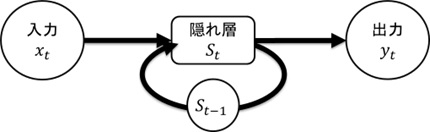

---

<small>
Recurrent Neural Network の'Recurrent'に対する邦訳は幾つかあります．リカレントニューラルネットワーク，回帰型ニューラルネットワーク，再帰型ニューラルネットワーク，循環型ニューラルネットワーク，など．
ただし，Recursive Neural Network（レキューシブニューラルネットワーク）を再帰型ニューラルネットワークと訳す場合もあるため注意してください．
また，連続値を推定するモデル全般（線形回帰，Elastic Net回帰，決定木回帰，...等）を「回帰」と呼びますが，この場合における「回帰」の原語は Regression です．要するに，英語では意味も単語も異なります．文脈で判別できないときは原語（英語）を確認してください．
<small>


# 目的：過去の気象情報から未来の気象情報を予測すること

使用するデータは，ドイツの都市イェーナ（Jena）にある[マックス・プランク生物地球化学研究所](https://www.bgc-jena.mpg.de/)が記録した[気象の時系列データ](https://www.bgc-jena.mpg.de/wetter/)です．

今回は，「[Deep Learning with Python](https://www.manning.com/books/deep-learning-with-python/)」（邦訳版：[Pythonによるディープラーニング](https://www.amazon.co.jp/Python%E3%81%AB%E3%82%88%E3%82%8B%E3%83%87%E3%82%A3%E3%83%BC%E3%83%97%E3%83%A9%E3%83%BC%E3%83%8B%E3%83%B3%E3%82%B0-Compass-Books%E3%82%B7%E3%83%AA%E3%83%BC%E3%82%BA-Fran%C3%A7ois-Chollet/dp/4839977739)）という書籍向けに著者 François Chollet によって準備されたデータセットを使用します．

なお，[マックス・プランク生物地球化学研究所](https://www.bgc-jena.mpg.de/)が提供する元々のデータセットは，[こちら](https://www.bgc-jena.mpg.de/wetter/weather_data.html)からダウンロード可能です．

<br>

---

このデータセットには，気温，気圧，湿度など，下記表に示す 15 の列が含まれます．収集間隔は 2003 年から 10 分間隔であり，今回は 2009 年から 2016 年までに収集された7年分の気象情報データのみを使用します．

<br>

　使える情報（入力データの種類）：下記表に示す15種類の気象情報データ <br>
　取得したい結果（出力データの種類）：**未来の（モデル訓練時に使用したデータの観測日時以降の）気象情報データ**

<br>

|列番号|列名|邦訳|概略|
|----|----|----|---|
|0|Date Time| 日時 | 観測日時（10分間隔） |
|1|p (mbar)| 気圧（ミリバール）|大気中の気体分子が地球表面に及ぼす力（大気の重さによって引き起こされる圧力）|
|2|T (degC)| 温度（摂氏）|物質の分子や原子の運動の速さやエネルギーの状態を表す指標|
|3|Tpot (K)|ポテンシャル温度（ケルビン）|参照気圧に基づく温度指標（気圧の変化に対し頑健な温度指標）|
|4|Tdew (degC) |露点温度（摂氏）|空気の水蒸気が飽和状態に達するときの温度（水蒸気の一部が液体に変わる温度）|
|5|rh (%) |相対湿度（パーセント）|ある温度における空気中に含まれる水蒸気の量とその温度での飽和水蒸気量との比|
|6|VPmax (mbar) |飽和水蒸気圧（ミリバール）|特定の温度において空気中の水蒸気が飽和状態に達したときの水蒸気の圧力を示す指標|
|7|VPact (mbar) |実効水蒸気圧（ミリバール）|空気中の水蒸気の圧力を示す指標|
|8|VPdef (mbar)|直訳：水蒸気圧の不足（ミリバール）|飽和水蒸気圧（VPmax）から実効水蒸気圧（VPact）を引いた値|
|9|sh (g/kg)| 比湿（グラム/キログラム）|大気中の水蒸気の質量を大気の質量で割った値|
|10|H2OC (mmol/mol) |水蒸気の量（モル分率）|水蒸気分子の数を空気中の全分子数で割った値（水蒸気が大気中の空気の中で占める割合を示す指標）|
|11|rho (g/m**3) |密度（グラム/立方メートル）|大気中の空気分子や気体成分の質量が占める単位体積あたりの割合を示す指標|
|12|wv (m/s) |風速（メートル/秒）|風が単位時間あたりに移動する距離（風の強さを表す指標）|
|13|max. wv (m/s) |最大風速（メートル/秒）|特定の時間枠内で観測された最も速い風を表す指標|
|14|wd (deg) |風の向き（度）|風がどの方角から吹いてくるかを示す指標|

<br>

参考資料：[TensorFlow Core チュートリアル 時系列予測](https://www.tensorflow.org/tutorials/structured_data/time_series?hl=ja)


## GPU の利用確認とTensorFlowのバージョン確認

In [ ]:
!nvidia-smi

Wed Jun  3 08:02:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import tensorflow as tf
import sklearn

print('TensorFlow version:',tf.__version__)
print('scikit-learn version:',sklearn.__version__)

if tf.__version__ != '2.20.0':
    !pip install -q --upgrade tensorflow==2.20.0
    print('TensorFlow version:',tf.__version__)

if sklearn.__version__ != '1.6.1':
    !pip install -q --upgrade scikit-learn==1.6.1
    print('scikit-learn version:',sklearn.__version__)

TensorFlow version: 2.20.0
scikit-learn version: 1.6.1


In [ ]:
!pip install -q japanize_matplotlib # matplotlib日本語化用の外部ライブラリ

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 34.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


### パッケージインポート

In [ ]:
import os # os：標準ライブラリ，OS依存の処理（環境変数やフォルダ作成など）を扱う
import datetime # datetime：標準ライブラリ，日付関連データを扱う
import random # random：標準ライブラリ，擬似乱数発生器
import numpy as np # numpy：数値計算用ライブラリの一つ
import pandas as pd # pandas：表計算用ライブラリの一つ
from IPython.display import display # Colabなどで一部のデータをprint()よりも綺麗に出力できる関数
import matplotlib.pylab as plt # matplotlib：グラフ描画用ライブラリの一つ
import seaborn as sns # seaborn：グラフ描画用ライブラリの一つ
from sklearn.metrics import classification_report # 機械学習ライブラリの一つ（今回はPrecision,Recall,F1-Scoreの出力時に使用するのみ）
# tensorboard：深層学習ライブラリTensorFlowのダッシュボード出力用設定
%load_ext tensorboard
import tensorflow as tf # TensorFlow：深層学習ライブラリ一つ

# scikit_learn：機械学習用のライブラリの一つ
from sklearn.preprocessing import StandardScaler

import japanize_matplotlib # matplotlib日本語化用の外部ライブラリ

### 擬似乱数発生器のrandom seed 固定

* 下記プログラム中で生成・使用される擬似乱数列を固定します．
* random seed は擬似乱数列を生成する時の初期化に使われる数値です．
* 明示的に指定しない場合は，時刻などで初期化されます．
* 今回は再現性を確保する（誰がいつ実行しても同じ擬似乱数列を生成させる）ために random seed を固定します．

<small> ※ colab では割り当てられるCPU/GPUやライブラリバージョンの違いにより，完全再現は難しい場合もあります.</small>

In [ ]:
def set_seed(seed=123):
    # hash seed の固定
    os.environ["PYTHONHASHSEED"] = str(seed)
    # Python外部ライブラリ：TensorFlow の ニューラルネットワークを決定論的に動作させる
    os.environ['TF_DETERMINISTIC_OPS'] = 'true'
    # Python外部ライブラリ：TensorFlow の ニューラルネットワークを決定論的に動作させる
    os.environ['TF_CUDNN_DETERMINISTIC'] = 'true'
    # Python標準ライブラリ：random の seed固定
    random.seed(seed)
    # Python外部ライブラリ：Numpy の seed固定
    np.random.seed(seed)
    # Python外部ライブラリ：TensorFlow の seed固定
    tf.random.set_seed(seed)

set_seed(42)

## データセットの取得


In [ ]:
zip_path = tf.keras.utils.get_file(
    origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname='jena_climate_2009_2016.csv.zip',
    extract=True)
csv_path, _ = os.path.splitext(zip_path)

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# このチュートリアルでは、時間ごとの予測のみを使用するため、
# 10 分間隔のデータを 1 時間間隔にサブサンプリングしましょう。

df = pd.read_csv(csv_path+"/jena_climate_2009_2016.csv")
print(f"10分間隔の表データサイズ：{df.shape}")
display(df.head(5))

# Slice [start:stop:step], starting from index 5 take every 6th record.
df = df[5::6]
print(f"\n1時間間隔の表データサイズ：{df.shape}")

display_df = df.copy()
date_time = pd.to_datetime(df.pop('Date Time'), format='%d.%m.%Y %H:%M:%S')
#display_df.index = date_time

#データをのぞいてみましょう。最初の数行は、次のようになっています。
display(display_df.head(5))

10分間隔の表データサイズ：(420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3



1時間間隔の表データサイズ：(70091, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
5,01.01.2009 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
11,01.01.2009 02:00:00,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,190.3
17,01.01.2009 03:00:00,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,0.18,0.63,167.2
23,01.01.2009 04:00:00,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0
29,01.01.2009 05:00:00,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,0.40,0.88,157.0


## データの確認

先ほどの表データを，日時をX軸とした折れ線グラフで描画します．


今回は気象データであるため，年単位の周期性（季節性）があると予想できます．
年周期の周期性を確認するため，全データを描画します．

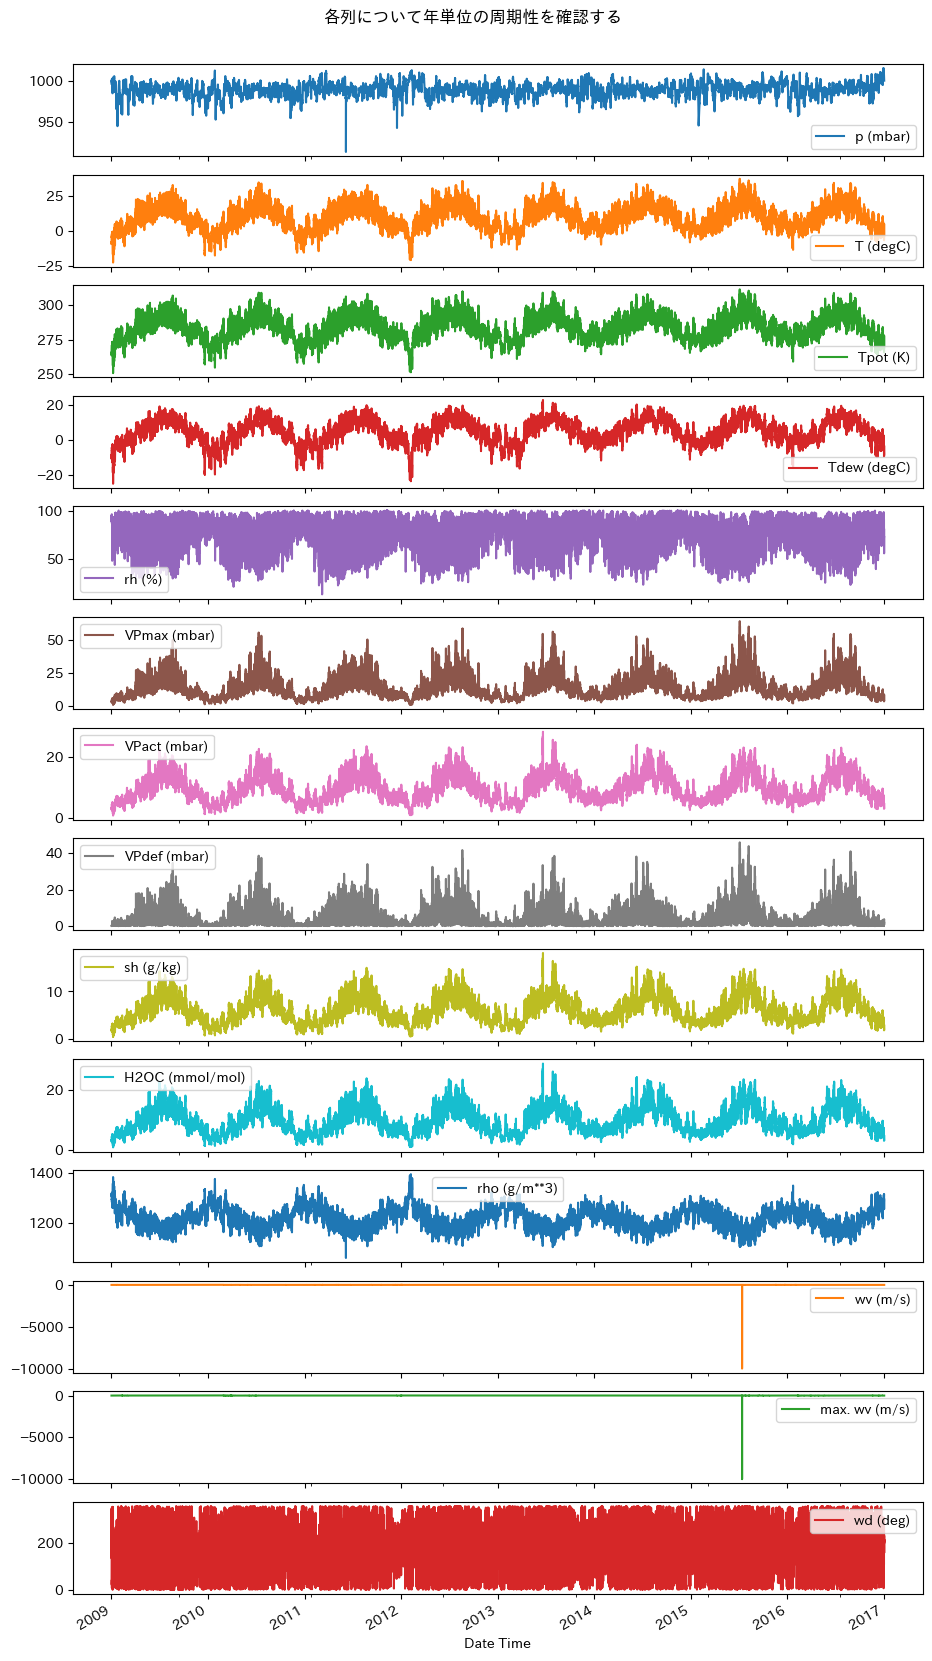

In [ ]:
# 全データの折れ線グラフを描画する

plot_features = df
plot_features.index = date_time
plot_features.plot(subplots=True, title='各列について年単位の周期性を確認する', kind='line',  figsize=(10,18))
plt.subplots_adjust(left=0.1, right=0.95, bottom=0.1, top=0.95)
plt.show()

一部の列では，明白な**周期性**を確認することができます．

また，気象データには，年単位の周期性だけでなく，日単位の周期性もあると予想されます（通常，夜間は気温が下がる）．


日周期の周期性を確認するため，先頭2週間分のデータについて折れ線グラフを描画します．

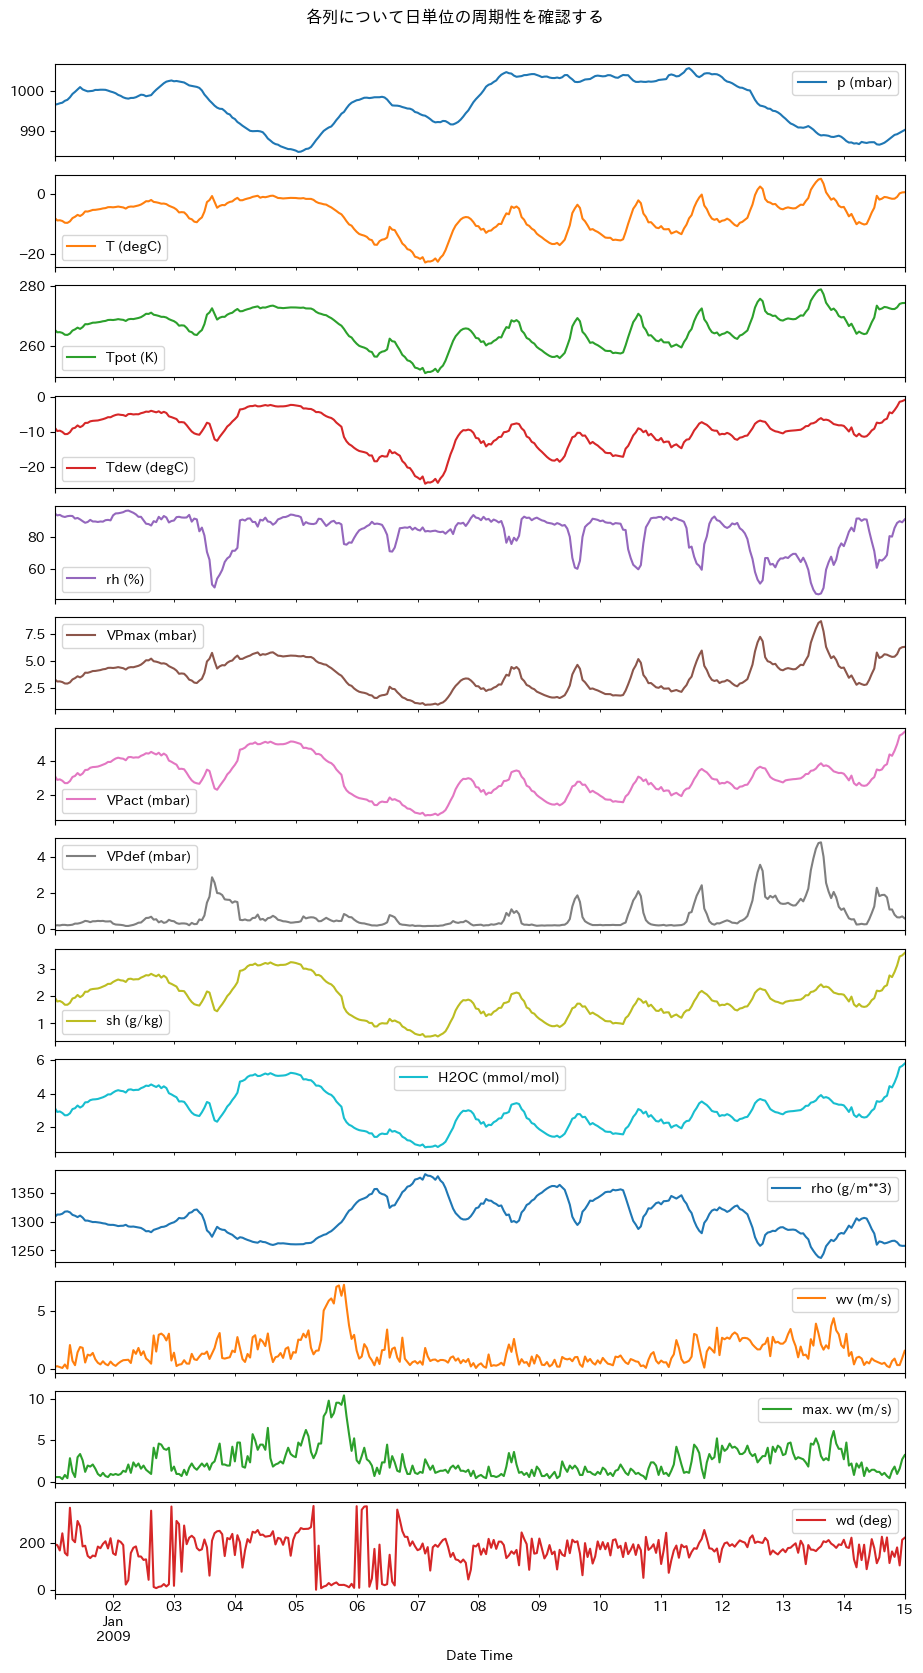

In [ ]:
# 先頭1週間分のデータについて折れ線グラフを描画する
# 1時間あたり1件のデータがあるため：24×14 = 336 件描画する．

plot_features = df[:336]
plot_features.index = date_time[:336]
_ = plot_features.plot(subplots=True, title='各列について日単位の周期性を確認する', kind='line',  figsize=(10,18))
plt.subplots_adjust(left=0.1, right=0.95, bottom=0.1, top=0.95)
plt.show()


また，2つのグラフ見比べると，風速の列：```wv (m/s)```と，最大風速の列：```max. wv (m/s)```には極端な外れ値があることが分かります．
各列の最小値と最大値を確認してみましょう．

In [ ]:
display(df.describe().transpose())

,count,mean,std,min,25%,50%,75%,max
p (mbar),70091.0,989.212842,8.358886,913.60,984.20,989.57,994.720,1015.29
T (degC),70091.0,9.450482,8.423384,-22.76,3.35,9.41,15.480,37.28
Tpot (K),70091.0,283.493086,8.504424,250.85,277.44,283.46,289.530,311.21
Tdew (degC),70091.0,4.956471,6.730081,-24.80,0.24,5.21,10.080,23.06
rh (%),70091.0,76.009788,16.474920,13.88,65.21,79.30,89.400,100.00
VPmax (mbar),70091.0,13.576576,7.739883,0.97,7.77,11.82,17.610,63.77
VPact (mbar),70091.0,9.533968,4.183658,0.81,6.22,8.86,12.360,28.25
VPdef (mbar),70091.0,4.042536,4.898549,0.00,0.87,2.19,5.300,46.01
sh (g/kg),70091.0,6.022560,2.655812,0.51,3.92,5.59,7.800,18.07
H2OC (mmol/mol),70091.0,9.640437,4.234862,0.81,6.29,8.96,12.490,28.74


## 異常値の処理


風速の列：```wv (m/s) ```の最小値と，最大風速の列：```max. wv (m/s)```の最小値は，```-9999```となっています．これは実際の風速ではない誤った値（計測機器のエラーなど）である可能性が高いです．


また，風向の列：```wd (deg)```があるため，正常に計測および集計できているならば，風速はゼロより大きい値（>=0）であるはずです．風速が0未満のデータは，0とするように加工を行います．


In [ ]:
# 異常値の処理を行う．

wv = df['wv (m/s)']
bad_wv = wv == -9999.0
wv[bad_wv] = 0.0

max_wv = df['max. wv (m/s)']
bad_max_wv = max_wv == -9999.0
max_wv[bad_max_wv] = 0.0


display(df['wv (m/s)'].min())


print("異常値の処理後：")
display(df.describe().transpose())

0.0

異常値の処理後：


,count,mean,std,min,25%,50%,75%,max
p (mbar),70091.0,989.212842,8.358886,913.60,984.20,989.57,994.720,1015.29
T (degC),70091.0,9.450482,8.423384,-22.76,3.35,9.41,15.480,37.28
Tpot (K),70091.0,283.493086,8.504424,250.85,277.44,283.46,289.530,311.21
Tdew (degC),70091.0,4.956471,6.730081,-24.80,0.24,5.21,10.080,23.06
rh (%),70091.0,76.009788,16.474920,13.88,65.21,79.30,89.400,100.00
VPmax (mbar),70091.0,13.576576,7.739883,0.97,7.77,11.82,17.610,63.77
VPact (mbar),70091.0,9.533968,4.183658,0.81,6.22,8.86,12.360,28.25
VPdef (mbar),70091.0,4.042536,4.898549,0.00,0.87,2.19,5.300,46.01
sh (g/kg),70091.0,6.022560,2.655812,0.51,3.92,5.59,7.800,18.07
H2OC (mmol/mol),70091.0,9.640437,4.234862,0.81,6.29,8.96,12.490,28.74


## 特徴量エンジニアリング

モデルの構築を始める前に，データを理解しておくことが重要です．また，モデルに適切にフォーマットされたデータを渡していることも確認する必要があります．

### 風

データの最後の列にある `wd (deg)` は，角度単位の風向を示します．角度は，モデルへの入力には適していません．360° と 0° は互いに近く，スムーズに回り込む必要があります．また，風が吹いていない場合は，向きは関係ありません．


例えば，359° と 0° は，単純な数値としては359の差がありますが，「角度」としては1°しか違わず，近い情報であることを意味しています．

このまま角度の数値を入力すると，「359° と 0°」の差（1°）が，「359°と350°」の差（9°）よりも小さな差であると扱うようにモデルは処理できません．



現時点では，風のデータの分布は次のようになっています．

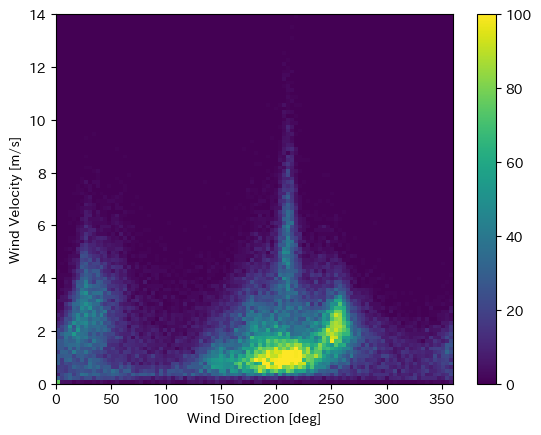

In [ ]:
plt.hist2d(df['wd (deg)'], df['wv (m/s)'], bins=(100, 100), vmax=100)
plt.colorbar()
plt.xlabel('Wind Direction [deg]')
plt.ylabel('Wind Velocity [m/s]')
plt.show()

ただし，風向と風速の列を風の**ベクトル**に変換すると，モデルにとって単純な分布になります．

風ベクトルのX成分とY成分の分布を可視化します．

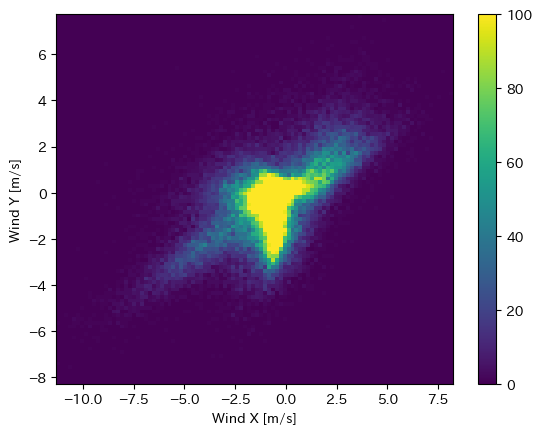

In [ ]:
wv = df.pop('wv (m/s)')
max_wv = df.pop('max. wv (m/s)')

# ラジアンへ変換する
wd_rad = df.pop('wd (deg)')*np.pi / 180

# 風速ベクトルの x 成分と y 成分を計算する
df['Wx'] = wv*np.cos(wd_rad)
df['Wy'] = wv*np.sin(wd_rad)

# 最大風速ベクトルの x 成分と y 成分を計算する
df['max Wx'] = max_wv*np.cos(wd_rad)
df['max Wy'] = max_wv*np.sin(wd_rad)

plt.hist2d(df['Wx'], df['Wy'], bins=(100, 100), vmax=100)
plt.colorbar()
plt.xlabel('Wind X [m/s]')
plt.ylabel('Wind Y [m/s]')
ax = plt.gca()
ax.axis('tight')
plt.show()

先ほどの角度の図では，本来は「近い」情報が右端と左端で不連続になっていました．しかし，上図のようにベクトルの分布では，そのようなことになっていません．

### 時刻

風向の角度情報と同様に，人間にとって`Date Time` 列は非常に便利ですが，モデルにとっては扱いにくいです．


例えば，59 と 0 は，単純な数値としては59の差がありますが，時刻の情報として，10:59:59の1秒後は，11:00:00になります．

そこで，秒に変換することにします．

In [ ]:
timestamp_s = date_time.map(pd.Timestamp.timestamp)

さらに，今回の時系列予測で扱うデータは，気象データであるため，明確な日単位および年単位の周期性があります．


周期の操作には様々な方法がありますが，今回は，sinとcosで明確な「Time of day（日周期）」と「Time of year（年周期）」信号に変換します．

In [ ]:
day = 24*60*60
year = (365.2425)*day

df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day)).values
df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day)).values
df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year)).values
df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year)).values

Text(0.5, 1.0, 'Time of day signal')

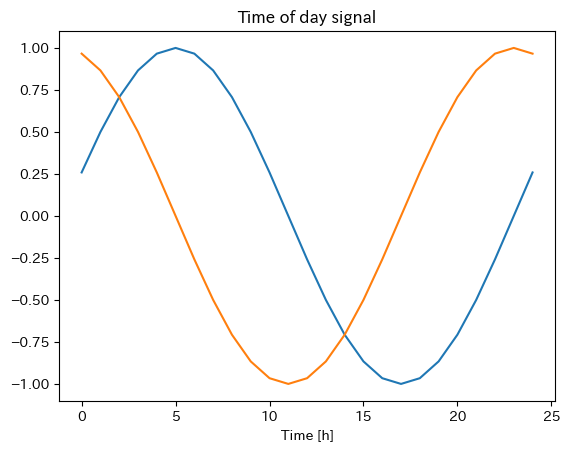

In [ ]:
plt.plot(np.array(df['Day sin'])[:25])
plt.plot(np.array(df['Day cos'])[:25])
plt.xlabel('Time [h]')
plt.title('Time of day signal')

このような加工を行うことで，モデルは殆どの重要な頻度特徴量（日周期・年周期）にアクセスできるようになります．

このデータの場合は，「気象データ」である，という情報から，予めどの周期が重要であるか予想することが可能でした．

そのような情報がない場合は，<a href="https://en.wikipedia.org/wiki/Fast_Fourier_transform" class="external">高速フーリエ変換</a>で特徴量を抽出し，どの周波数が重要であるかを判断することができます．予想を確認するために，以下に，時間の経過に伴う気温の `tf.signal.rfft` を示します．`1/year` と `1/day` に近い周波数で明確なピークを確認することができます．

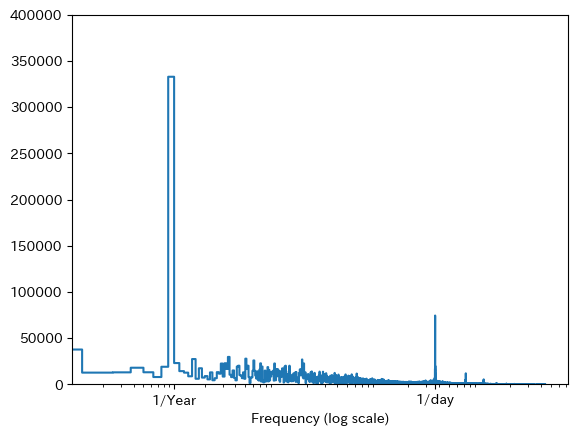

In [ ]:
fft = tf.signal.rfft(df['T (degC)'])
f_per_dataset = np.arange(0, len(fft))

n_samples_h = len(df['T (degC)'])
hours_per_year = 24*365.2524
years_per_dataset = n_samples_h/(hours_per_year)

f_per_year = f_per_dataset/years_per_dataset
plt.step(f_per_year, np.abs(fft))
plt.xscale('log')
plt.ylim(0, 400000)
plt.xlim([0.1, max(plt.xlim())])
plt.xticks([1, 365.2524], labels=['1/Year', '1/day'])
_ = plt.xlabel('Frequency (log scale)')

### 折れ線グラフを描画する

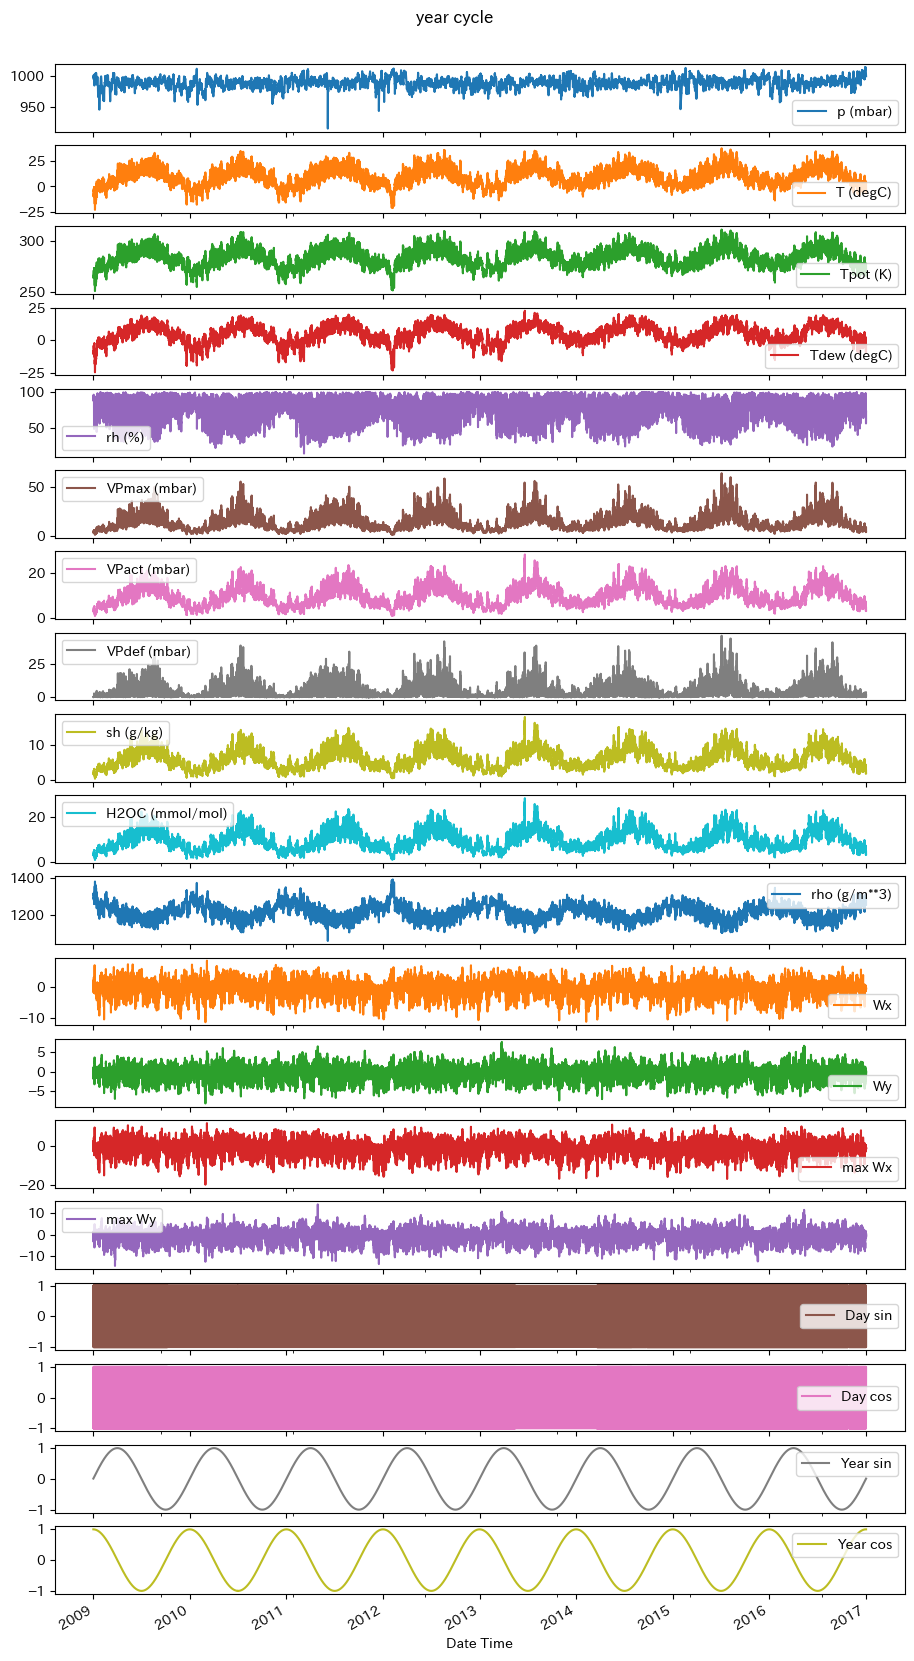

In [ ]:
# 全データの折れ線グラフを描画する

plot_features = df
plot_features.index = date_time
plot_features.plot(subplots=True, title='year cycle', kind='line',  figsize=(10,18))
plt.subplots_adjust(left=0.1, right=0.95, bottom=0.1, top=0.95)
plt.show()

## モデルへ入力するデータ（特徴量エンジニアリング後）

特徴量エンジニアリングを行った後のデータをおさらいします．
これがモデルへの入出力データとなります．

|列番号|列名|邦訳|概略|
|----|----|----|---|
|【index】|Date Time|日時|観測日時（1時間間隔）|
|0|p (mbar)| 気圧（ミリバール）|大気中の気体分子が地球表面に及ぼす力（大気の重さによって引き起こされる圧力）|
|1|T (degC)| 温度（摂氏）|物質の分子や原子の運動の速さやエネルギーの状態を表す指標|
|2|Tpot (K)|ポテンシャル温度（ケルビン）|参照気圧に基づく温度指標（気圧の変化に対し頑健な温度指標）|
|3|Tdew (degC) |露点温度（摂氏）|空気の水蒸気が飽和状態に達するときの温度（水蒸気の一部が液体に変わる温度）|
|4|rh (%) |相対湿度（パーセント）|ある温度における空気中に含まれる水蒸気の量とその温度での飽和水蒸気量との比|
|5|VPmax (mbar) |飽和水蒸気圧（ミリバール）|特定の温度において空気中の水蒸気が飽和状態に達したときの水蒸気の圧力を示す指標|
|6|VPact (mbar) |実効水蒸気圧（ミリバール）|空気中の水蒸気の圧力を示す指標|
|7|VPdef (mbar)|直訳：水蒸気圧の不足（ミリバール）|飽和水蒸気圧（VPmax）から実効水蒸気圧（VPact）を引いた値|
|8|sh (g/kg)| 比湿（グラム/キログラム）|大気中の水蒸気の質量を大気の質量で割った値|
|9|H2OC (mmol/mol) |水蒸気の量（モル分率）|水蒸気分子の数を空気中の全分子数で割った値（水蒸気が大気中の空気の中で占める割合を示す指標）|
|10|rho (g/m**3) |密度（グラム/立方メートル）|大気中の空気分子や気体成分の質量が占める単位体積あたりの割合を示す指標|
|11|Wx|風速ベクトルのx成分|風の強さと向きを表す指標|
|12|Wy |風速ベクトルのy成分|風の強さと向きを表す指標|
|13|max Wx|最大風速ベクトルのx成分|特定の時間枠内で観測された最も速い風の強さと向きを表す指標|
|14|max Wy |最大風速ベクトルのy成分|特定の時間枠内で観測された最も速い風の強さと向きを表す指標|
|15|Day sin |日単位の周期成分（sin）|日単位の周期性へモデルがアクセスしやすくするための列|
|16|Day cos |日単位の周期成分（cos）|日単位の周期性へモデルがアクセスしやすくするための列|
|17|Year sin |日単位の周期成分（sin）|年単位の周期性へモデルがアクセスしやすくするための列|
|18|Year cos |日単位の周期成分（cos）|年位の周期性へモデルがアクセスしやすくするための列|



## データセットの分割

訓練用データセット，検証用データセット，テスト用データセットに分割を行います．
過去のデータから未来のデータを予測するため，時系列順に分割しています．

In [ ]:

column_indices = {name: i for i, name in enumerate(df.columns)}

n = len(df)
train_df = df[0:int(n*0.7)]
valid_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

num_features = df.shape[1]

print("訓練用データ（先頭5行）")
display(train_df.head(5))
print()
print("検証用データ（先頭5行）")
display(valid_df.head(5))
print()
print("テスト用データ（先頭5行）")
display(test_df.head(5))

訓練用データ（先頭5行）


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,,,,,,,,,,,,,,,
2009-01-01 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,-0.204862,-0.046168,-0.614587,-0.138503,0.258819,0.965926,0.010049,0.999950
2009-01-01 02:00:00,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,-0.245971,-0.044701,-0.619848,-0.112645,0.500000,0.866025,0.010766,0.999942
2009-01-01 03:00:00,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,-0.175527,0.039879,-0.614344,0.139576,0.707107,0.707107,0.011483,0.999934
2009-01-01 04:00:00,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,-0.050000,-0.086603,-0.190000,-0.329090,0.866025,0.500000,0.012199,0.999926
2009-01-01 05:00:00,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,-0.368202,0.156292,-0.810044,0.343843,0.965926,0.258819,0.012916,0.999917



検証用データ（先頭5行）


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,,,,,,,,,,,,,,,
2014-08-05 02:10:00,990.43,14.46,288.41,13.81,95.9,16.49,15.82,0.68,9.99,15.97,1192.35,-0.448741,-1.389328,-0.682332,-2.112540,0.537300,0.843391,-0.549225,-0.835674
2014-08-05 03:10:00,990.66,13.83,287.76,13.39,97.2,15.83,15.39,0.44,9.72,15.53,1195.44,-0.449278,-0.756670,-0.714760,-1.203793,0.737277,0.675590,-0.549824,-0.835280
2014-08-05 04:10:00,990.80,13.53,287.45,13.31,98.6,15.53,15.31,0.22,9.67,15.45,1196.90,-1.518657,0.592100,-2.608735,1.017103,0.887011,0.461749,-0.550423,-0.834886
2014-08-05 05:10:00,990.96,13.33,287.24,13.16,98.9,15.33,15.16,0.17,9.57,15.29,1198.00,-0.768007,-0.855958,-1.175385,-1.309988,0.976296,0.216440,-0.551021,-0.834491
2014-08-05 06:10:00,991.10,13.46,287.35,13.35,99.3,15.46,15.35,0.11,9.69,15.49,1197.54,-1.443201,-0.220841,-2.253766,-0.344875,0.999048,-0.043619,-0.551619,-0.834096



テスト用データ（先頭5行）


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,,,,,,,,,,,,,,,
2016-03-11 20:00:00,1001.93,2.80,275.81,1.25,89.5,7.47,6.69,0.78,4.16,6.68,1261.61,2.674455,1.336933,3.908819,1.953979,-8.660254e-01,0.500000,0.937670,0.347527
2016-03-11 21:00:00,1002.38,2.75,275.72,0.67,86.1,7.45,6.41,1.04,3.99,6.40,1262.54,2.836975,0.944286,4.943357,1.645394,-7.071068e-01,0.707107,0.937919,0.346855
2016-03-11 22:00:00,1002.63,2.46,275.41,0.46,86.6,7.29,6.32,0.98,3.93,6.30,1264.24,2.748864,1.298208,3.553630,1.678276,-5.000000e-01,0.866025,0.938167,0.346183
2016-03-11 23:00:00,1002.48,1.93,274.90,0.82,92.3,7.03,6.48,0.54,4.03,6.47,1266.37,1.506908,1.919070,2.352999,2.996580,-2.588190e-01,0.965926,0.938415,0.345510
2016-03-12 00:00:00,1002.42,1.87,274.84,0.76,92.3,6.99,6.45,0.54,4.01,6.44,1266.63,3.037622,1.614452,4.565263,2.426371,-1.801868e-12,1.000000,0.938662,0.344837


## データの標準化処理


ニューラルネットワーク（NN）は，データの列（種別）毎に，数値の大きさが大きく異なると，数値が大きいデータ列に比重が置かれてしまいます．

```
例：人間の身長[cm]と体重[kg]

cm単位で記録された身長のデータが格納された列と，kg単位で記録された体重のデータがある場合，身長の列の方が全体的に数値が大きくなります．
このようなデータでそのままニューラルネットワークを訓練させると，数値が大きい身長の情報に比重を置いて学習してしまいやすくなります．
```

このような事態を防ぐため，ニューラルネットワークを訓練させる場合は．各列の数値の大きさを合わせる処理（スケーリング）が必要です．標準化は，平均を0，分散を1とするスケーリング手法です．

$$ x_{std}  = \frac{x - \bar{x}}{s}$$
$x$が標準化を行う前のデータ（各列），$ \bar{x} $は$x$の平均値，$s$は$x$の標準偏差，$x_{std}$ が標準化が行われた後のデータです．

In [ ]:
# 標準化処理前のデータセット先頭5行を表示
display(train_df.head(5))

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,,,,,,,,,,,,,,,
2009-01-01 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,-0.204862,-0.046168,-0.614587,-0.138503,0.258819,0.965926,0.010049,0.999950
2009-01-01 02:00:00,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,-0.245971,-0.044701,-0.619848,-0.112645,0.500000,0.866025,0.010766,0.999942
2009-01-01 03:00:00,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,-0.175527,0.039879,-0.614344,0.139576,0.707107,0.707107,0.011483,0.999934
2009-01-01 04:00:00,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,-0.050000,-0.086603,-0.190000,-0.329090,0.866025,0.500000,0.012199,0.999926
2009-01-01 05:00:00,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,-0.368202,0.156292,-0.810044,0.343843,0.965926,0.258819,0.012916,0.999917


In [ ]:
# 標準化処理

scaler = StandardScaler()
# 標準化処理には，平均値と標準偏差が必要である．
# ここでは，訓練用データセットの平均値と標準偏差を使用して，
# 訓練用データセット/検証用データセット/評価用データセットの標準化処理を行う
scaler.fit(train_df)

train_col = train_df.columns
train_idx = train_df.index
valid_col = valid_df.columns
valid_idx = valid_df.index
test_col = test_df.columns
test_idx = test_df.index


train_df = pd.DataFrame( scaler.transform(train_df), columns = train_col, index = train_idx )
valid_df = pd.DataFrame( scaler.transform(valid_df), columns = valid_col, index = valid_idx )
test_df = pd.DataFrame( scaler.transform(test_df), columns = test_col, index = test_idx )


# 標準化処理後のデータセット先頭5行を表示
display(train_df.head(5))

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,,,,,,,,,,,,,,,
2009-01-01 01:00:00,0.945317,-1.982493,-2.041909,-1.918992,1.117113,-1.302864,-1.477338,-0.790432,-1.480051,-1.482712,2.218546,0.193411,0.221164,0.111142,0.217930,0.366114,1.366083,-0.061053,1.428449
2009-01-01 02:00:00,0.959780,-2.078393,-2.138188,-2.060985,1.044628,-1.330156,-1.534370,-0.786280,-1.536205,-1.539050,2.325731,0.172989,0.222103,0.109459,0.227801,0.707207,1.224807,-0.060030,1.428438
2009-01-01 03:00:00,0.986294,-2.070305,-2.132457,-2.045208,1.062749,-1.328857,-1.527241,-0.788356,-1.528718,-1.532008,2.324022,0.207985,0.276269,0.111219,0.324082,1.000110,1.000069,-0.059007,1.428427
2009-01-01 04:00:00,1.004372,-2.098035,-2.161112,-2.096841,1.008386,-1.336654,-1.546251,-0.782129,-1.547436,-1.553135,2.358937,0.270346,0.195269,0.246910,0.145177,1.224862,0.707186,-0.057984,1.428415
2009-01-01 05:00:00,1.061016,-2.165050,-2.232175,-2.187200,0.984224,-1.353549,-1.579519,-0.782129,-1.581129,-1.585998,2.446345,0.112265,0.350822,0.048641,0.402057,1.366147,0.366116,-0.056961,1.428402


## データのウィンドウ処理

今回のモデルは，時系列データの連続するサンプル点のウィンドウ（窓，区間）に基づき，それより未来にあたる区間の予測を立てます．

入力ウィンドウの主な特徴量は次のようになります．

- 入力ウィンドウの幅とラベルウィンドウの幅（時間ステップ数）
- それらの時間offset（訓練に使用する区間を基準とした予測したい区間の位置）
- どの特徴量が入力データであるか，正解ラベルであるか，その両方として使用されるか


例えば，
* 24 時間先の単一予測を立てるにあたり，過去 24 時間の履歴を指定するときのウィンドウ定義は，
![ウィンドウ例1](https://www.tensorflow.org/static/tutorials/structured_data/images/raw_window_24h.png?hl=ja, "過去24時間のデータから24時間先の単一予測を行う")

* 1時間先の単一予測を立てるにあたり，過去 6 時間の履歴を指定するときのウィンドウ定義は，
![ウィンドウ例2](https://www.tensorflow.org/static/tutorials/structured_data/images/raw_window_1h.png?hl=ja, "過去24時間のデータから24時間先の単一予測を行う")




このようなデータウィンドウ処理を簡便におこなうための機能を実装するため，```WindowGenerator``` クラスを定義します．これは次のような機能をもっています．

1. indexとoffsetを、上図のように処理する．
2. 特徴量のウィンドウを `(features, labels)` ペアに分割する．
3. 結果ウィンドウの中身をプロットする．
4. 訓練用データ，検証用データ，テスト用データから，これらのウィンドウのバッチを，`tf.data.Dataset` を使用して効率的に生成する．

In [ ]:
class WindowGenerator():
    def __init__(self, input_width, label_width, shift,
                train_df=train_df, valid_df=valid_df, test_df=test_df,
                batch_size=32, label_columns=None):

        # 入力時のデータを保持する
        self.train_df = train_df
        self.valid_df = valid_df
        self.test_df = test_df

        # batch_sizeで指定したバッチサイズの設定を保持する
        self.batch_size = batch_size

        # label_columnsで指定した列のindexを代入する
        self.label_columns = label_columns
        if label_columns is not None:
            self.label_columns_indices = {name: i for i, name in
                                            enumerate(label_columns)}
        self.column_indices = {name: i for i, name in
                            enumerate(train_df.columns)}

        # ウィンドウパラメータを代入する
        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift

        self.total_window_size = input_width + shift

        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]

        self.label_start = self.total_window_size - self.label_width
        self.labels_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

    def __repr__(self):
        return '\n'.join([
            f'Total window size: {self.total_window_size}',
            f'Input indices: {self.input_indices}',
            f'Label indices: {self.label_indices}',
            f'Label column name(s): {self.label_columns}'])

    # リストの連続入力がある場合，これらを入力のウィンドウとラベルのウィンドウに変換する．
    def split_window(self, features):
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.labels_slice, :]
        if self.label_columns is not None:
            labels = tf.stack(
                [labels[:, :, self.column_indices[name]] for name in self.label_columns],
                axis=-1)


        # スライスでは静的な形状情報が保持されないため，形状を手動で設定する
        # （tf.data.Datasetsで形状情報を使用するため）
        inputs.set_shape([None, self.input_width, None])
        labels.set_shape([None, self.label_width, None])

        return inputs, labels

    # 時系列の DataFrame を取得し，
    # tf.keras.utils.timeseries_dataset_from_array 関数を使用して，
    # (input_window, label_window) ペアの tf.data.Dataset に変換する
    def make_dataset(self, data):
        data = np.array(data, dtype=np.float32)
        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=data,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=True,
            batch_size=self.batch_size)

        ds = ds.map(self.split_window)
        return ds

    # 分割したウィンドウを可視化するための描画用
    def plot(self, model=None, plot_col='T (degC)', max_subplots=3):
        inputs, labels = self.example
        plt.figure(figsize=(12, 8))
        plot_col_index = self.column_indices[plot_col]
        max_n = min(max_subplots, len(inputs))
        for n in range(max_n):
            plt.subplot(max_n, 1, n+1)
            plt.ylabel(f'{plot_col} [normed]')
            plt.plot(self.input_indices, inputs[n, :, plot_col_index],
                    label='Inputs', marker='.', zorder=-10)

            if self.label_columns:
                label_col_index = self.label_columns_indices.get(plot_col, None)
            else:
                label_col_index = plot_col_index

            if label_col_index is None:
                continue

            plt.scatter(self.label_indices, labels[n, :, label_col_index],
                        edgecolors='k', label='Labels', c='#2ca02c', s=64)
            if model is not None:
                predictions = model(inputs)
                plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                            marker='X', edgecolors='k', label='Predictions',
                            c='#ff7f0e', s=64)

            if n == 0:
                plt.legend()
        plt.xlabel('Time [h]')



    @property
    def train(self):
        return self.make_dataset(self.train_df)

    @property
    def valid(self):
        return self.make_dataset(self.valid_df)

    @property
    def test(self):
        return self.make_dataset(self.test_df)

    @property
    def example(self):
        #プロット用の「入力，ラベル」のサンプル バッチを取得してキャッシュする．
        result = getattr(self, '_example', None)
        if result is None:
            # result の中身（サンプル用バッチ）が取得できなかった場合：
            # `.train` データセットからバッチを取得する
            result = next(iter(self.train))
            # 次回のためにキャッシュする．
            self._example = result
        return result


出力は次のようになります．

* 24 時間先の単一予測を立てるにあたり，過去 24 時間の履歴を指定するときのウィンドウ定義は，
![ウィンドウ例1](https://www.tensorflow.org/static/tutorials/structured_data/images/raw_window_24h.png?hl=ja, "過去24時間のデータから24時間先の単一予測を行う")

In [ ]:
# 24 時間先の単一予測を立てるにあたり，過去 24 時間の履歴を指定するときのウィンドウ定義
w1 = WindowGenerator(input_width=24, label_width=1, shift=24,
                     label_columns=['T (degC)'])
display(w1)

Total window size: 48
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [47]
Label column name(s): ['T (degC)']

* 1時間先の単一予測を立てるにあたり，過去 6 時間の履歴を指定するときのウィンドウ定義は，
![ウィンドウ例2](https://www.tensorflow.org/static/tutorials/structured_data/images/raw_window_1h.png?hl=ja, "過去24時間のデータから24時間先の単一予測を行う")

In [ ]:
# 1時間先の単一予測を立てるにあたり，過去 6 時間の履歴を指定するときのウィンドウ定義
w2 = WindowGenerator(input_width=6, label_width=1, shift=1,
                     label_columns=['T (degC)'])
display(w2)

Total window size: 7
Input indices: [0 1 2 3 4 5]
Label indices: [6]
Label column name(s): ['T (degC)']

リストの連続入力がある場合，`split_window` メソッドはこれらを入力のウィンドウとラベルのウィンドウに変換します．

前に定義した例の `w2` は次のように分割されます．

![ウィンドウはすべて連続したサンプルで，これを (inputs, labels) ペアに分割](https://www.tensorflow.org/static/tutorials/structured_data/images/split_window.png?hl=ja, "ウィンドウはすべて連続したサンプルで，これを（inputs, labels）ペアに分割")

この図ではデータの `features` 軸を表示しませんが，この `split_window` 関数は、`label_columns` も処理するため，単一出力でも複数出力でも使用できます．


次のセルで，リストの連続入力を行っています．

In [ ]:
# 合計ウィンドウの長さに相当する 3 つのスライスを積み重ねる
example_window = tf.stack([np.array(train_df[:w2.total_window_size]),
                           np.array(train_df[100:100+w2.total_window_size]),
                           np.array(train_df[200:200+w2.total_window_size])])

example_inputs, example_labels = w2.split_window(example_window)

print('All shapes are: (batch, time, features)')
print(f'Window shape: {example_window.shape}')
print(f'Inputs shape: {example_inputs.shape}')
print(f'Labels shape: {example_labels.shape}')

All shapes are: (batch, time, features)
Window shape: (3, 7, 19)
Inputs shape: (3, 6, 19)
Labels shape: (3, 1, 1)


通常 TensorFlow のデータは，最も外側のインデックスがサンプル全体とある配列です（これが「batch size（バッチサイズ）」次元）．

中央のインデックスは，「time」または「space」（width, height）次元です．

そして，最も内側のインデックスは特徴量の種類数です．

上記のコードは，バッチサイズを3，ステップウィンドウ幅を7時間，各時間ステップに 19 個の特徴量を取りました．

これを， 6 時間ステップかつ特徴量入力を19個，1時間ステップかつ正解ラベルを1つの特徴量に，分割しました．

<br>

正解ラベルは，```WindowGenerator``` の ```label_columns```で指定しています．上のw2では```label_columns=['T (degC)']``` として，気温の列のみを正解ラベルとしていました．

これ以降は，全ての特徴量（19列）を正解ラベルとして指定します．



```WindowGenerator``` オブジェクトにより，```tf.data.Dataset``` オブジェクトにアクセスできるようになったため，指定したウィンドウ幅でデータを簡単に出力できるようになりました．

```Dataset.element_spec``` で，データセット要素の構造，データ型，形状を確認できます．

In [ ]:
# (入力, 正解ラベル)のペアになっています．
display(w2.train.element_spec)

(TensorSpec(shape=(None, 6, 19), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 1, 1), dtype=tf.float32, name=None))

In [ ]:
# Datasetを反復処理（for文など）すると，バッチが生成されます．
for example_inputs, example_labels in w2.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')

Inputs shape (batch, time, features): (32, 6, 19)
Labels shape (batch, time, features): (32, 1, 1)


## 単一時間ステップモデル


このような時系列データで構築できる最も単純なモデルは，現在の条件のみに基づき，1 時間ステップ（1 時間）先の単一の特徴量の値を予測するモデルです．

つまり，1 時間先の気温：``` T (degC) ```を予測するモデルとなります．


![シングルステップモデル](https://www.tensorflow.org/static/tutorials/structured_data/images/narrow_window.png?hl=ja, "シングルステップモデル")


しかし，予測結果のサンプルが 1 つしかないと，描画しても良い予測結果なのか悪い予測結果なのか分かりにくいため，24 時間連続入力とラベルのウィンドウを一度に生成する``` WindowGenerator ```を作成します．

モデルは引き続き，1 つの入力時間ステップに基づいて 1 時間先の予測を立てます．
各予測は，時間ステップ間で相互作用のない独立した予測となっています．


![シングルステップモデル（24時間分連続）](https://www.tensorflow.org/static/tutorials/structured_data/images/lstm_many_window.png?hl=ja, "シングルステップモデル（24時間分連続）")






Total window size: 25
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Label column name(s): ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'Wx', 'Wy', 'max Wx', 'max Wy', 'Day sin', 'Day cos', 'Year sin', 'Year cos']


入力データの形状を確認する
Inputs shape (batch, time, features): (512, 24, 19)
Labels shape (batch, time, features): (512, 24, 19)


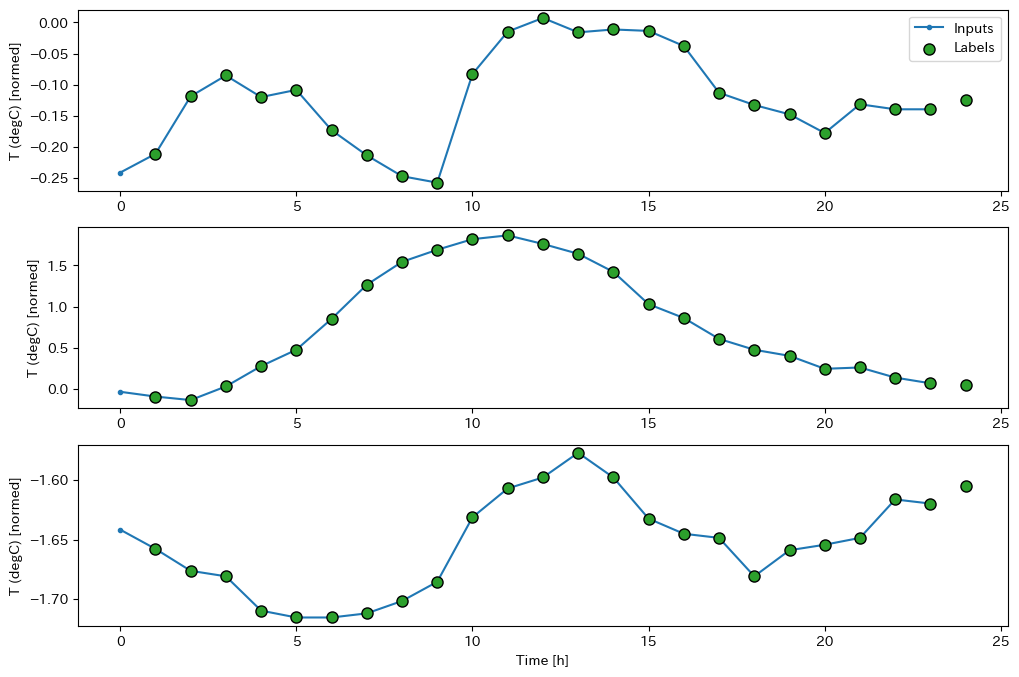

In [ ]:
wide_window = WindowGenerator(
    input_width=24, label_width=24, shift=1, \
    batch_size=512, label_columns=['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)',
       'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'Wx', 'Wy', 'max Wx', 'max Wy',
       'Day sin', 'Day cos', 'Year sin', 'Year cos'])

# ここでは気温列のみ描画します．
wide_window.plot(plot_col='T (degC)')
display(wide_window)

print("\n入力データの形状を確認する")
for example_inputs, example_labels in wide_window.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')

### RNNモデル定義

In [ ]:

# input層（入力層）：(time × features チャンネル)
inputs = tf.keras.layers.Input(shape = (24, num_features), name = 'input')

# (batch_size, time, features) -> (batch_size, time, rnn_units)
x = tf.keras.layers.SimpleRNN(units=32, return_sequences=True, name='rnn')(inputs)

# (batch, time, rnn_units) ->  (batch, time, features)
outputs = tf.keras.layers.Dense( units= num_features )(x)

# モデルを定義
model = tf.keras.Model( inputs = inputs, outputs = outputs, name = 'rnn_model' )

# モデルの構造をテキストで出力
model.summary()

Model: "rnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 24, 19)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (SimpleRNN)                 │ (None, 24, 32)         │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24, 19)         │           627 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,291 (8.95 KB)

 Trainable params: 2,291 (8.95 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 訓練中のログファイルを作成する準備
callbacks = []
callbacks.append(tf.keras.callbacks.CSVLogger('training_log_single.csv'))


# モデルのコンパイル（最適化アルゴリズム・損失関数・評価指標などを設定）
# 損失関数は2.6章で学びます．
model.compile(loss=tf.losses.MeanSquaredError(), # 損失関数
                   optimizer=tf.optimizers.Adam(), #最適化アルゴリズム
                   metrics=[tf.metrics.MeanAbsoluteError(),#監視用の指標（モデルの訓練そのものには影響しない）
                            tf.metrics.MeanAbsolutePercentageError(),
                            ])

history = model.fit(wide_window.train,
                    epochs = 10,
                    validation_data = wide_window.valid,
                    callbacks = callbacks
                    )

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - loss: 0.5822 - mean_absolute_error: 0.5658 - mean_absolute_percentage_error: 1125.6797 - val_loss: 0.2630 - val_mean_absolute_error: 0.3782 - val_mean_absolute_percentage_error: 2694.5010
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 0.1911 - mean_absolute_error: 0.3137 - mean_absolute_percentage_error: 751.5435 - val_loss: 0.1485 - val_mean_absolute_error: 0.2669 - val_mean_absolute_percentage_error: 2057.5854
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - loss: 0.1307 - mean_absolute_error: 0.2472 - mean_absolute_percentage_error: 573.3654 - val_loss: 0.1164 - val_mean_absolute_error: 0.2262 - val_mean_absolute_percentage_error: 1616.7191
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.1089 - mean_absolute_error: 0.2169 - mean_absolute_percentage_error: 474.6924 - val_loss: 0.1005 - val_mean_absolute_error: 0.2024 - val_mean_absolute_percentage_error: 1305.8265
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 

### 訓練中の損失関数と評価指標の推移を描画する

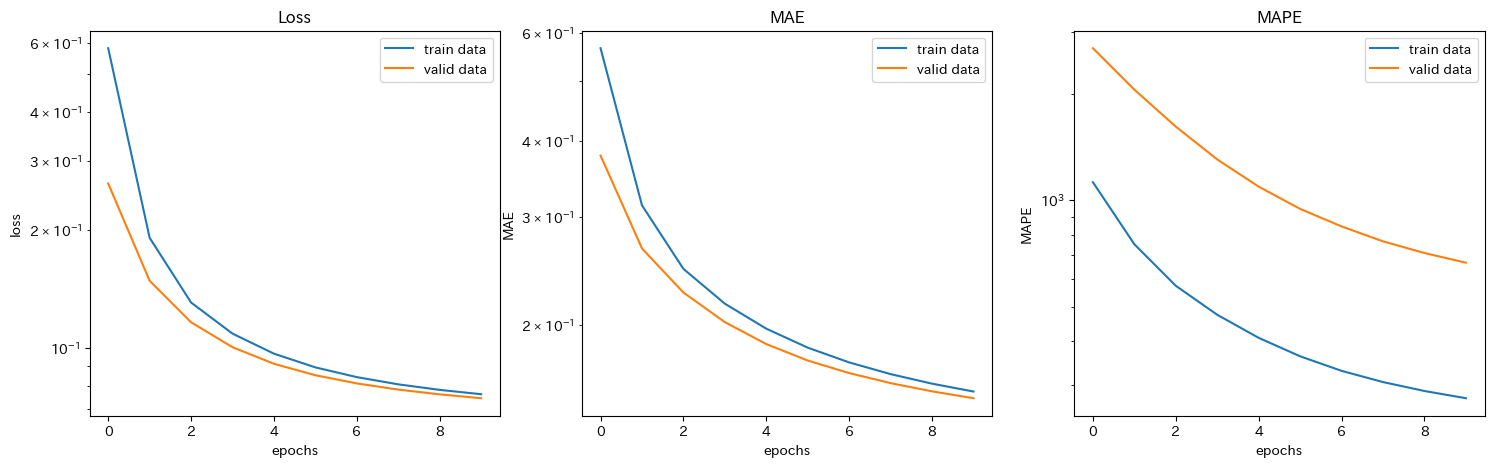

In [ ]:
log_df = pd.read_csv('training_log_single.csv')

epochs = log_df["epoch"].values

train_loss = log_df["loss"].values
train_mae = log_df['mean_absolute_error'].values
train_mape = log_df['mean_absolute_percentage_error'].values

valid_loss = log_df["val_loss"].values
valid_mae = log_df['val_mean_absolute_error'].values
valid_mape = log_df['val_mean_absolute_percentage_error'].values


fig, axes = plt.subplots(1,3, figsize=(18,5))

axes[0].plot(epochs, train_loss, label="train data")
axes[0].plot(epochs, valid_loss, label="valid data")
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss")
axes[0].legend(loc="upper right")
axes[0].set_title("Loss")
axes[0].set_yscale("log")

axes[1].plot(epochs, train_mae, label="train data")
axes[1].plot(epochs, valid_mae, label="valid data")
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("MAE")
axes[1].legend(loc="upper right")
axes[1].set_title("MAE")
axes[1].set_yscale("log")


axes[2].plot(epochs, train_mape, label="train data")
axes[2].plot(epochs, valid_mape, label="valid data")
axes[2].set_xlabel("epochs")
axes[2].set_ylabel("MAPE")
axes[2].legend(loc="upper right")
axes[2].set_title("MAPE")
axes[2].set_yscale("log")


plt.show()

### 推論結果の可視化

96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 0.0754 - mean_absolute_error: 0.1540 - mean_absolute_percentage_error: 269.6256
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0745 - mean_absolute_error: 0.1521 - mean_absolute_percentage_error: 666.4489


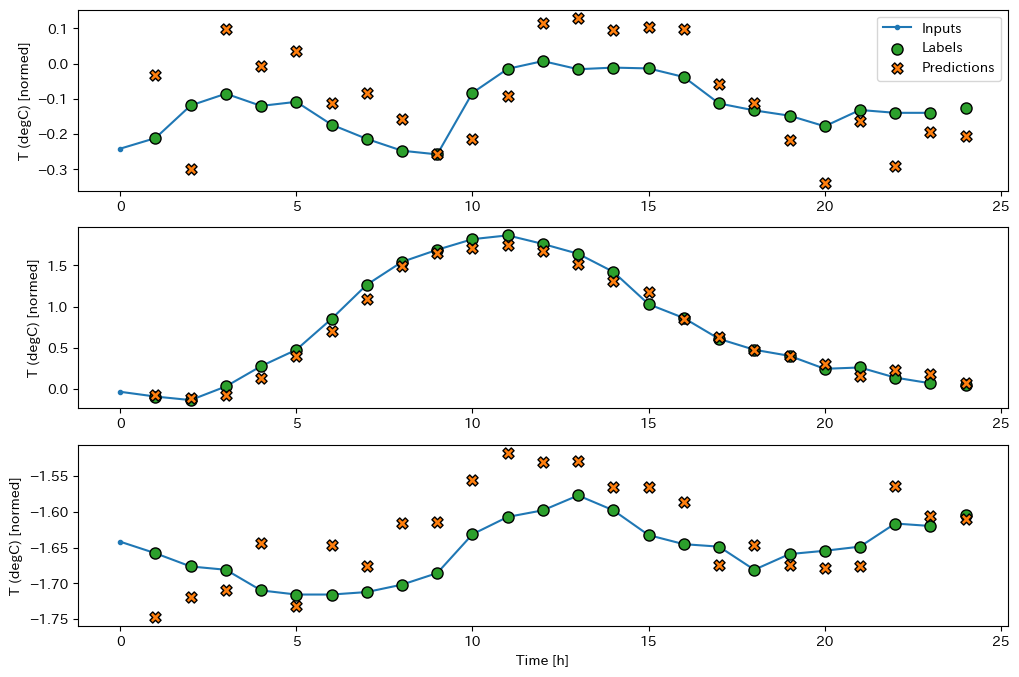

In [ ]:
train_performance = {}
valid_performance = {}
test_performance = {}

train_performance['RNN(single step)'] = model.evaluate( wide_window.train, return_dict=True)
valid_performance['RNN(single step)'] = model.evaluate( wide_window.valid, return_dict=True)
test_performance['RNN(single step)'] = model.evaluate( wide_window.test, return_dict=True, verbose=0)
# ここでは気温列のみ可視化する
wide_window.plot(model, plot_col='T (degC)')

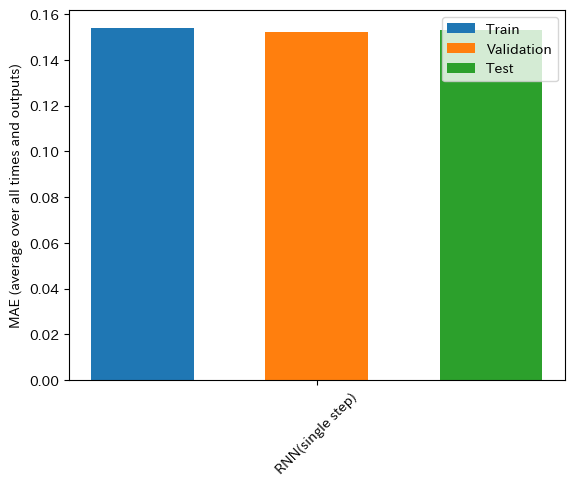

In [ ]:
x = np.arange(len(train_performance))
width = 0.1

metric_name = 'mean_absolute_error'

train_mae = [v[metric_name] for v in train_performance.values()]
valid_mae = [v[metric_name] for v in valid_performance.values()]
test_mae = [v[metric_name] for v in test_performance.values()]

plt.bar(x - 0.17, train_mae, width, label='Train')
plt.bar(x, valid_mae, width, label='Validation')
plt.bar(x + 0.17, test_mae, width, label='Test')
plt.xticks(ticks=x, labels=train_performance.keys(),
           rotation=45)
plt.ylabel(f'MAE (average over all times and outputs)')
_ = plt.legend()

## 複数時間ステップモデル（シングルショット）

ここまで，1 時間先までの単一時間ステップ予測を行いました．


しかし，「1時間先の気象情報予測データ」の需要は，それほど大きくありません．


おそらく皆さんも，「朝時点の」ニュースなどで「夕方・夜間の気象情報予測」を見て，
傘や上着を持っていくかどうかを決めるのではないでしょうか．


ここからは，単一時間ステップモデルを拡張し，複数時間ステップモデルを作成します．

複数ステップ予測では，モデルは将来の値の範囲を予測できるように学習する必要があります．従って，未来の1 つのデータ点を予測するだけの単一ステップモデルとは異なり，複数ステップモデルは，未来の一連のデータ点を予測します．

これには，大まかに 2 つの手法があります．

**①時系列全体を一度に予測するシングルショット予測**<br>
**②モデルは単一ステップ予測を行い，その出力（モデルの予測値）を次の入力とする，自動回帰（AutoRegressive）予測**

<br>

---

<br>

①複数ステップモデル（シングルショット）では，訓練用データは1時間ごとのデータ点で構成されますが，ここでは，過去 24 時間のデータがある場合に，モデルは 24 時間先を予測するように学習します．

![マルチステップ（シングルショット）](https://www.tensorflow.org/static/tutorials/structured_data/images/multistep_lstm.png?hl=ja, "マルチステップ（シングルショット）")


次のコードセルは，データセットからこれらのスライスを生成する Window オブジェクトです．

Total window size: 48
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47]
Label column name(s): ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'Wx', 'Wy', 'max Wx', 'max Wy', 'Day sin', 'Day cos', 'Year sin', 'Year cos']

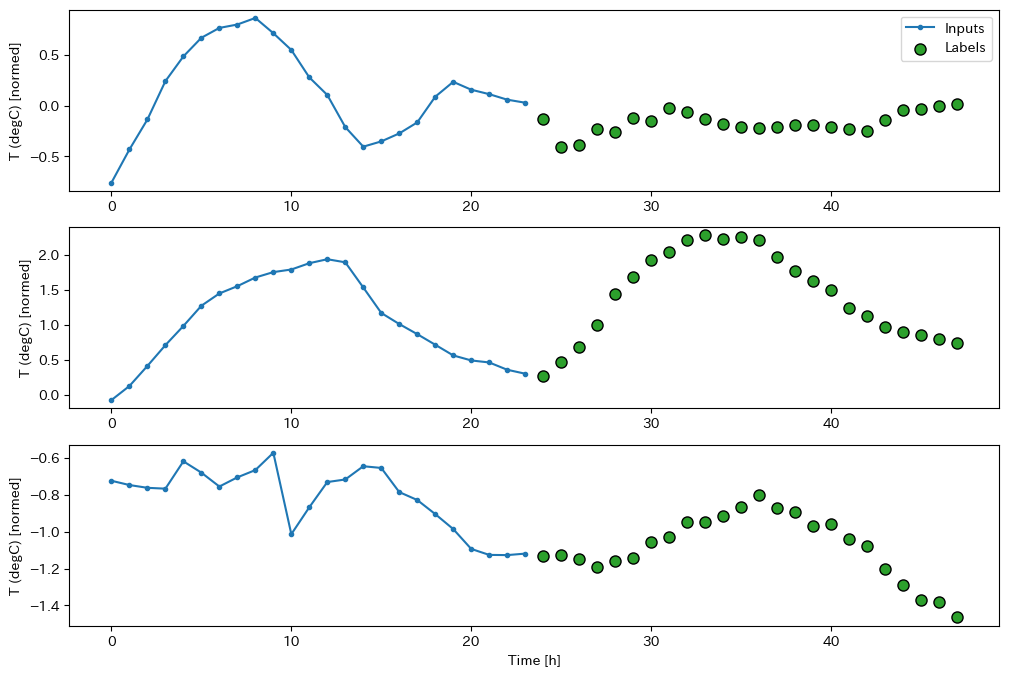

In [ ]:
OUT_STEPS = 24
multi_window = WindowGenerator(input_width=24,
                               label_width=OUT_STEPS,
                               shift=OUT_STEPS,
                               batch_size=512,
                               label_columns=['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)',
       'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'Wx', 'Wy', 'max Wx', 'max Wy',
       'Day sin', 'Day cos', 'Year sin', 'Year cos']
                               )

# ここでは気温列のみ描画します．
multi_window.plot(plot_col='T (degC)')
multi_window

### RNNモデル定義（シングルショット）

In [ ]:
# input層（入力層）：(batch × time × featuresチャンネル)
inputs = tf.keras.layers.Input(shape = (24, num_features), name = 'input')

#  (batch, time, features) -> (batch, time, rnn_units)
x = tf.keras.layers.SimpleRNN(units=32, return_sequences=False, name='rnn')(inputs)

# (batch, time, rnn_units) -> (batch, time, out_steps*features)
x = tf.keras.layers.Dense(units = OUT_STEPS * num_features, \
                          kernel_initializer=tf.initializers.zeros())(x)

# (batch, time, out_steps*features) -> (batch, out_steps, features)
outputs = tf.keras.layers.Reshape([OUT_STEPS, num_features])(x)

# モデルを定義
multi_step_model = tf.keras.Model(inputs = inputs, outputs = outputs, name = 'rnn_multi_step_model' )

# モデルの構造をテキストで出力
multi_step_model.summary()

Model: "rnn_multi_step_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 24, 19)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (SimpleRNN)                 │ (None, 32)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 456)            │        15,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 24, 19)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,712 (65.28 KB)

 Trainable params: 16,712 (65.28 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 訓練中のログファイルを作成する準備
callbacks = []
callbacks.append(tf.keras.callbacks.CSVLogger('training_log_multi.csv'))

# モデルのコンパイル（最適化アルゴリズム・損失関数・評価指標などを設定）
# 損失関数は2.6章で学びます．
multi_step_model.compile(loss=tf.losses.MeanSquaredError(), # 損失関数
                   optimizer=tf.optimizers.Adam(), #最適化アルゴリズム
                   metrics=[tf.metrics.MeanAbsoluteError(),#監視用の指標（モデルの訓練そのものには影響しない）
                            tf.metrics.MeanAbsolutePercentageError(),
                            ])

history = multi_step_model.fit(multi_window.train,
                         epochs = 10,
                         validation_data = multi_window.valid,
                         callbacks = callbacks
                         )


Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - loss: 0.5812 - mean_absolute_error: 0.5764 - mean_absolute_percentage_error: 424.1281 - val_loss: 0.3725 - val_mean_absolute_error: 0.4426 - val_mean_absolute_percentage_error: 2041.0399
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.3225 - mean_absolute_error: 0.4009 - mean_absolute_percentage_error: 602.7510 - val_loss: 0.2914 - val_mean_absolute_error: 0.3717 - val_mean_absolute_percentage_error: 1667.2998
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - loss: 0.2828 - mean_absolute_error: 0.3649 - mean_absolute_percentage_error: 549.7376 - val_loss: 0.2729 - val_mean_absolute_error: 0.3523 - val_mean_absolute_percentage_error: 1433.0830
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.2668 - mean_absolute_error: 0.3482 - mean_absolute_percentage_error: 508.2773 - val_loss: 0.2619 - val_mean_absolute_error: 0.3401 - val_mean_absolute_percentage_error: 1305.0989
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s

### 訓練中の損失関数と評価指標の推移を描画する

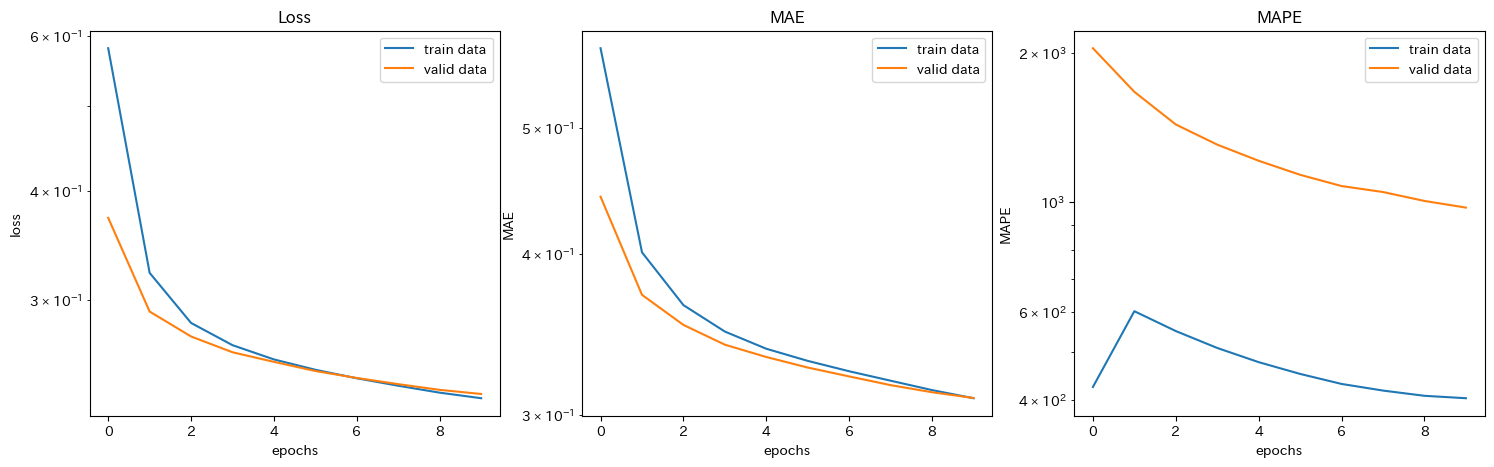

In [ ]:
log_df = pd.read_csv('training_log_multi.csv')

epochs = log_df["epoch"].values

train_loss = log_df["loss"].values
train_mae = log_df['mean_absolute_error'].values
train_mape = log_df['mean_absolute_percentage_error'].values

valid_loss = log_df["val_loss"].values
valid_mae = log_df['val_mean_absolute_error'].values
valid_mape = log_df['val_mean_absolute_percentage_error'].values


fig, axes = plt.subplots(1,3, figsize=(18,5))

axes[0].plot(epochs, train_loss, label="train data")
axes[0].plot(epochs, valid_loss, label="valid data")
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss")
axes[0].legend(loc="upper right")
axes[0].set_title("Loss")
axes[0].set_yscale("log")

axes[1].plot(epochs, train_mae, label="train data")
axes[1].plot(epochs, valid_mae, label="valid data")
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("MAE")
axes[1].legend(loc="upper right")
axes[1].set_title("MAE")
axes[1].set_yscale("log")


axes[2].plot(epochs, train_mape, label="train data")
axes[2].plot(epochs, valid_mape, label="valid data")
axes[2].set_xlabel("epochs")
axes[2].set_ylabel("MAPE")
axes[2].legend(loc="upper right")
axes[2].set_title("MAPE")
axes[2].set_yscale("log")


plt.show()

### 推論結果の可視化

96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.2306 - mean_absolute_error: 0.3077 - mean_absolute_percentage_error: 405.6939
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.2347 - mean_absolute_error: 0.3094 - mean_absolute_percentage_error: 974.6338


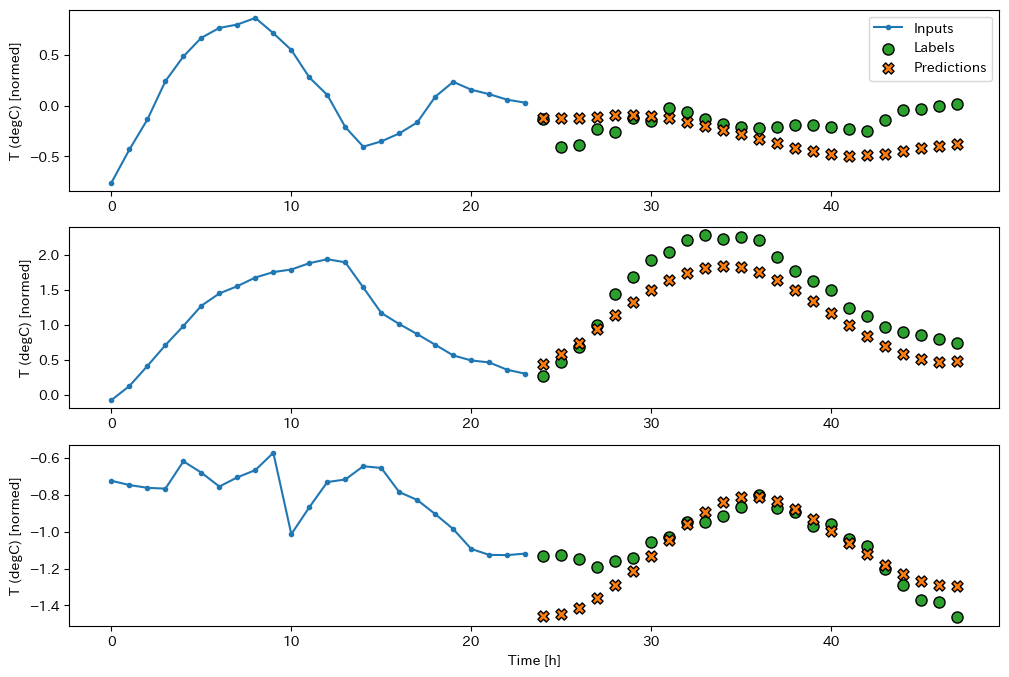

In [ ]:
train_performance['RNN(multi step, single shot)'] = multi_step_model.evaluate( multi_window.train, return_dict=True)
valid_performance['RNN(multi step, single shot)'] = multi_step_model.evaluate( multi_window.valid, return_dict=True)
test_performance['RNN(multi step, single shot)'] = multi_step_model.evaluate( multi_window.test, return_dict=True, verbose=0)

# ここでは気温列のみ描画します．
multi_window.plot(multi_step_model, plot_col='T (degC)')

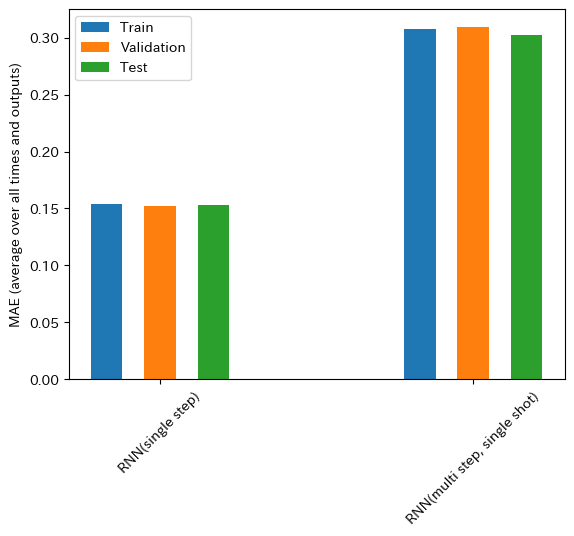

In [ ]:
x = np.arange(len(train_performance))
width = 0.1

metric_name = 'mean_absolute_error'

train_mae = [v[metric_name] for v in train_performance.values()]
valid_mae = [v[metric_name] for v in valid_performance.values()]
test_mae = [v[metric_name] for v in test_performance.values()]

plt.bar(x - 0.17, train_mae, width, label='Train')
plt.bar(x, valid_mae, width, label='Validation')
plt.bar(x + 0.17, test_mae, width, label='Test')
plt.xticks(ticks=x, labels=train_performance.keys(),
           rotation=45)
plt.ylabel(f'MAE (average over all times and outputs)')
_ = plt.legend()

1時間前の気象情報データを使用しているRNN（single step）と比較すると，24時間前までの気象情報データのみを使用しているRNN（multi step, single shot）の精度は悪くなっています．

予測したい時刻の直前までデータを収集してモデルを訓練させて予測をすれば，確かに「精度の良いモデル」を作成しやすいですが，そのようなモデルは需要が低い場合が殆どです（1時間後の気象情報データの需要が低いように）．

需要と精度のバランスも見極める必要があります．



## 複数時間ステップモデル（自動回帰/AutoRegressive）

ここまでモデルはすべて，単一のステップで，出力データ区間の全体を予測します．

一部のケースでは，モデルの予測を個別の時間ステップに分解すると，予測に役立てることができる可能性があります．

各モデルの出力を各ステップの次の入力で使用し，前ステップの予測値に基づいて，次ステップの予測を立てることができます．

この手法のモデルは，長さの異なる出力を生成するように構築できる利点もあります．

![マルチステップモデル（自動回帰）](https://www.tensorflow.org/static/tutorials/structured_data/images/multistep_autoregressive.png?hl=ja, "マルチステップモデル（自動回帰）")

Total window size: 48
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47]
Label column name(s): ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'Wx', 'Wy', 'max Wx', 'max Wy', 'Day sin', 'Day cos', 'Year sin', 'Year cos']

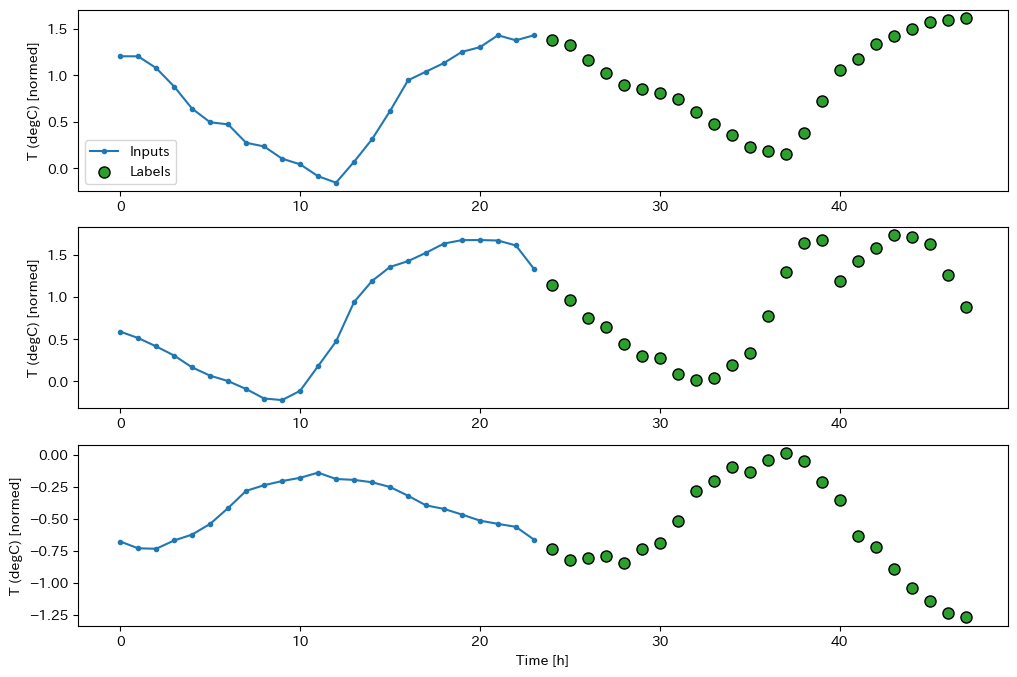

In [ ]:
OUT_STEPS = 24
feedback_window = WindowGenerator(input_width=24,
                               label_width=OUT_STEPS,
                               shift=OUT_STEPS,
                               batch_size=512,
                               label_columns=['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)',
       'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'Wx', 'Wy', 'max Wx', 'max Wy',
       'Day sin', 'Day cos', 'Year sin', 'Year cos']
                               )

# ここでは気温列のみ描画します．
feedback_window.plot(plot_col='T (degC)')
feedback_window

### 自動回帰モデル（AutoRegressive model）定義

In [ ]:
class FeedBack(tf.keras.Model):
    def __init__(self, units, out_steps):
        super().__init__()
        self.out_steps = out_steps
        self.units = units
        self.lstm_cell = tf.keras.layers.LSTMCell(units)
        # LSTMCellをRNNでラップすることで，`warmup`メソッドを簡素化
        self.lstm_rnn = tf.keras.layers.RNN(self.lstm_cell, return_state=True)
        self.dense = tf.keras.layers.Dense(num_features)

    def warmup(self, inputs):
        # inputs.shape -> (batch, time, features)
        # x.shape -> (batch, lstm_units)
        x, *state = self.lstm_rnn(inputs)

        # predictions.shape -> (batch, features)
        prediction = self.dense(x)
        return prediction, state

    def call(self, inputs, training=None):
        # TensorArrayを使用し動的に展開された出力をキャプチャ
        predictions = []
        # LSTMの状態を初期化
        prediction, state = self.warmup(inputs)

        # 最初の予測を挿入
        predictions.append(prediction)

        # 残りの予測ステップを実行
        for n in range(1, self.out_steps):
            # 前回の予測を入力として使用
            x = prediction
            # LSTMステップを1回実行
            x, state = self.lstm_cell(x, states=state, training=training)
            # LSTMの出力を予測に変換
            prediction = self.dense(x)
            # 予測を出力に追加
            predictions.append(prediction)

        # predictions.shape -> (time, batch, features)
        predictions = tf.stack(predictions)
        # predictions.shape -> (batch, time, features)
        predictions = tf.transpose(predictions, [1, 0, 2])
        return predictions

# モデルを定義
feedback_model = FeedBack(units=32, out_steps=OUT_STEPS)

feedback_model.build(input_shape=(None,24, num_features))
# モデルの構造をテキストで出力
feedback_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'feed_back', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "feed_back"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_cell (LSTMCell)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (RNN)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 訓練中のログファイルを作成する準備
callbacks = []
callbacks.append(tf.keras.callbacks.CSVLogger('training_log_autoReg.csv'))

# モデルのコンパイル（最適化アルゴリズム・損失関数・評価指標などを設定）
# 損失関数は2.6章で学びます．
feedback_model.compile(loss=tf.losses.MeanSquaredError(), # 損失関数
                         optimizer=tf.optimizers.Adam(),#最適化アルゴリズム
                         metrics=[tf.metrics.MeanAbsoluteError(),#監視用の指標（モデルの訓練そのものには影響しない）
                                  tf.metrics.MeanAbsolutePercentageError()
                                  ])

history = feedback_model.fit(feedback_window.train,
                         epochs = 10,
                         validation_data = feedback_window.valid,
                         callbacks = callbacks
                         )

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 111ms/step - loss: 0.6555 - mean_absolute_error: 0.6195 - mean_absolute_percentage_error: 516.4131 - val_loss: 0.4940 - val_mean_absolute_error: 0.5159 - val_mean_absolute_percentage_error: 1521.5735
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - loss: 0.4479 - mean_absolute_error: 0.4931 - mean_absolute_percentage_error: 503.8359 - val_loss: 0.3852 - val_mean_absolute_error: 0.4533 - val_mean_absolute_percentage_error: 1491.2050
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.3157 - mean_absolute_error: 0.4023 - mean_absolute_percentage_error: 584.7013 - val_loss: 0.2816 - val_mean_absolute_error: 0.3685 - val_mean_absolute_percentage_error: 1631.7104
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - loss: 0.2621 - mean_absolute_error: 0.3521 - mean_absolute_percentage_error: 521.7661 - val_loss: 0.2635 - val_mean_absolute_error: 0.3491 - val_mean_absolute_percentage_error: 1405.9904
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━

### 訓練中の損失関数と評価指標の推移を描画する

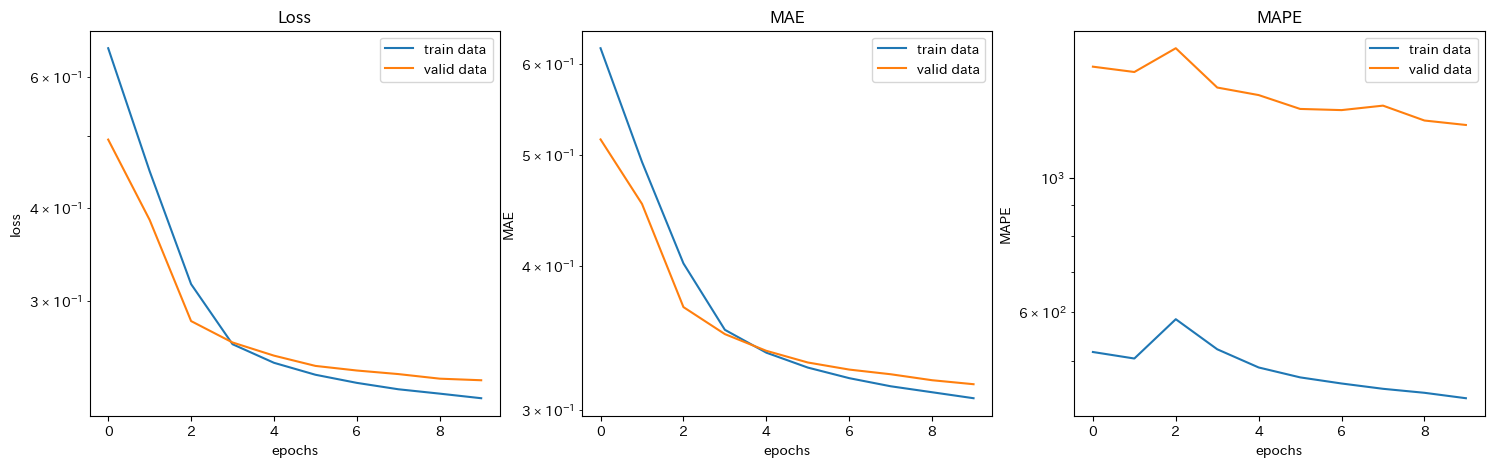

In [ ]:
log_df = pd.read_csv('training_log_autoReg.csv')

epochs = log_df["epoch"].values

train_loss = log_df["loss"].values
train_mae = log_df['mean_absolute_error'].values
train_mape = log_df['mean_absolute_percentage_error'].values

valid_loss = log_df["val_loss"].values
valid_mae = log_df['val_mean_absolute_error'].values
valid_mape = log_df['val_mean_absolute_percentage_error'].values


fig, axes = plt.subplots(1,3, figsize=(18,5))

axes[0].plot(epochs, train_loss, label="train data")
axes[0].plot(epochs, valid_loss, label="valid data")
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss")
axes[0].legend(loc="upper right")
axes[0].set_title("Loss")
axes[0].set_yscale("log")

axes[1].plot(epochs, train_mae, label="train data")
axes[1].plot(epochs, valid_mae, label="valid data")
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("MAE")
axes[1].legend(loc="upper right")
axes[1].set_title("MAE")
axes[1].set_yscale("log")


axes[2].plot(epochs, train_mape, label="train data")
axes[2].plot(epochs, valid_mape, label="valid data")
axes[2].set_xlabel("epochs")
axes[2].set_ylabel("MAPE")
axes[2].legend(loc="upper right")
axes[2].set_title("MAPE")
axes[2].set_yscale("log")


plt.show()

### 推論結果の可視化

96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.2205 - mean_absolute_error: 0.3056 - mean_absolute_percentage_error: 436.1826
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.2344 - mean_absolute_error: 0.3157 - mean_absolute_percentage_error: 1220.1461


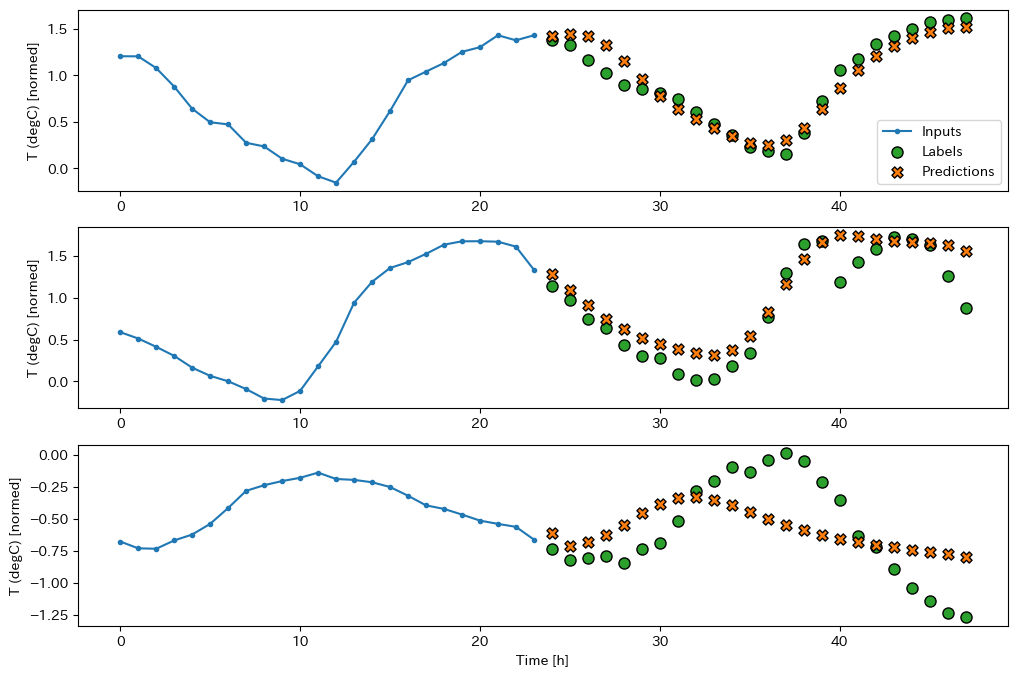

In [ ]:
train_performance['RNN(multi step, feedback)'] = feedback_model.evaluate( feedback_window.train, return_dict=True)
valid_performance['RNN(multi step, feedback)'] = feedback_model.evaluate( feedback_window.valid, return_dict=True)
test_performance['RNN(multi step, feedback)'] = feedback_model.evaluate( feedback_window.test, return_dict=True, verbose=0)

# ここでは気温列のみ描画します．
feedback_window.plot(feedback_model, plot_col='T (degC)')

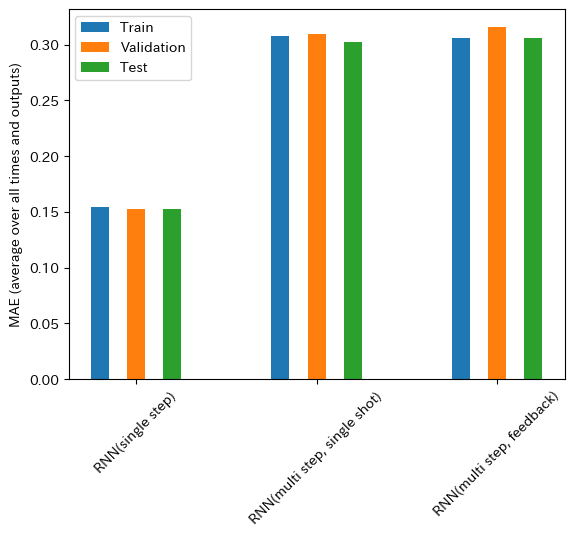

In [ ]:
x = np.arange(len(train_performance))
width = 0.1

metric_name = 'mean_absolute_error'

train_mae = [v[metric_name] for v in train_performance.values()]
valid_mae = [v[metric_name] for v in valid_performance.values()]
test_mae = [v[metric_name] for v in test_performance.values()]

plt.bar(x - 0.2, train_mae, width, label='Train')
plt.bar(x,       valid_mae, width, label='Validation')
plt.bar(x + 0.2, test_mae, width, label='Test')
plt.xticks(ticks=x, labels=train_performance.keys(),
           rotation=45)
plt.ylabel(f'MAE (average over all times and outputs)')
_ = plt.legend()

この気象情報データにおいては，RNN（multi step, single shot）とRNN（multi step, feedback）の精度が今のところ同じくらいとなっています．

ただし，特徴量エンジニアリング，モデル構成，モデルの損失関数・最適化アルゴリズム・Epoch数などを工夫すると，異なる結果となる可能性もあります．